In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [2]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"
df = pd.read_csv(URL)
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


In [3]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [4]:
df.shape

(2112, 15)

In [5]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

# Task 1.1

In [6]:
df_sales = df.groupby('Year')['Automobile_Sales'].mean()
df_sales

Year
1980     590.020455
1981     549.170233
1982     731.627451
1983    4350.265306
1984    4018.361702
1985    4664.409091
1986    2817.954545
1987    3033.638298
1988    4152.224490
1989    4435.021277
1990    1981.480000
1991     611.440217
1992    2186.622222
1993    2881.096154
1994    3559.921569
1995    7429.660377
1996    2623.148936
1997    3306.422222
1998    3826.937500
1999    3176.224490
2000    1966.553191
2001     796.480769
2002    1994.740741
2003    3638.823529
2004    4957.620000
2005    4888.816327
2006    3126.261176
2007    2782.901961
2008    2143.108696
2009     558.615000
2010    3728.740000
2011    4105.617021
2012    3655.142857
2013    2798.269231
2014    3483.067857
2015    4219.830189
2016    3478.238095
2017    3739.142857
2018    4482.739130
2019    4050.895833
2020    3016.521739
2021    3813.221224
2022    2724.466667
2023    3510.954545
Name: Automobile_Sales, dtype: float64

In [11]:
years_list = list(range(1980,2024))
years_list

[1980,
 1981,
 1982,
 1983,
 1984,
 1985,
 1986,
 1987,
 1988,
 1989,
 1990,
 1991,
 1992,
 1993,
 1994,
 1995,
 1996,
 1997,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023]

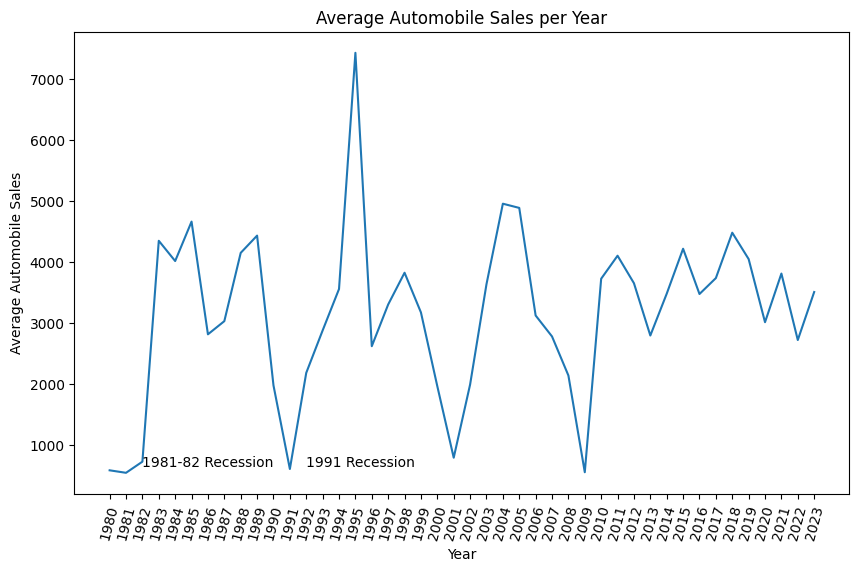

In [16]:
plt.figure(figsize=(10,6))
df_sales.plot(kind='line')
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.xticks(years_list,rotation = 75 )
plt.title("Average Automobile Sales per Year")
plt.text(1982, 650, '1981-82 Recession')
plt.text(1992,650, '1991 Recession')
plt.show()

# Task 1.2

In [17]:
df_filtered = df[df['Recession']==0]
df_filtered

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
138,1983-01-31,1983,Jan,0,87.49,0.45,32048,2943.0,8,22.29,-1.33,3.2,288.0,MediumFamilyCar,Illinois
139,1983-01-31,1983,Jan,0,87.49,0.37,58002,2943.0,8,22.29,-1.33,3.2,308.0,ExecutiveCar,Illinois
140,1983-01-31,1983,Jan,0,87.49,0.42,15526,2943.0,8,22.29,-1.33,3.2,309.0,SuperMiniCar,Illinois
141,1983-02-28,1983,Feb,0,126.06,0.44,18224,4621.0,4,12.82,-1.12,2.4,1874.0,SuperMiniCar,Georgia
142,1983-02-28,1983,Feb,0,126.06,0.37,36233,4621.0,4,12.82,-1.12,2.4,1922.0,MediumFamilyCar,Georgia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2107,2023-11-30,2023,Nov,0,97.09,0.90,76617,4850.0,5,27.90,0.30,2.9,2098.0,Sports,Georgia
2108,2023-12-31,2023,Dec,0,95.92,1.31,25506,2319.0,3,13.52,-1.06,2.1,7797.0,SmallFamilyCar,Georgia
2109,2023-12-31,2023,Dec,0,95.92,1.10,35319,2319.0,3,13.52,-1.06,2.1,7836.0,MediumFamilyCar,Georgia
2110,2023-12-31,2023,Dec,0,95.92,1.49,56767,2319.0,3,13.52,-1.06,2.1,7786.0,ExecutiveCar,Georgia


In [22]:
df_corr = df_filtered.groupby('Year',as_index=False).agg(
    avg_sales = ('Automobile_Sales','mean'),
    avg_adv_sales  =  ('Advertising_Expenditure','mean')
)
df_corr

,Year,avg_sales,avg_adv_sales
0,1983,4350.265306,3297.183673
1,1984,4018.361702,3289.021277
2,1985,4664.409091,3192.545455
3,1986,2817.954545,2978.204545
4,1987,3033.638298,3136.531915
5,1988,4152.224490,2948.061224
6,1989,4435.021277,2995.787234
7,1990,1981.480000,2982.000000
8,1992,2186.622222,3475.222222
9,1993,2881.096154,3556.230769


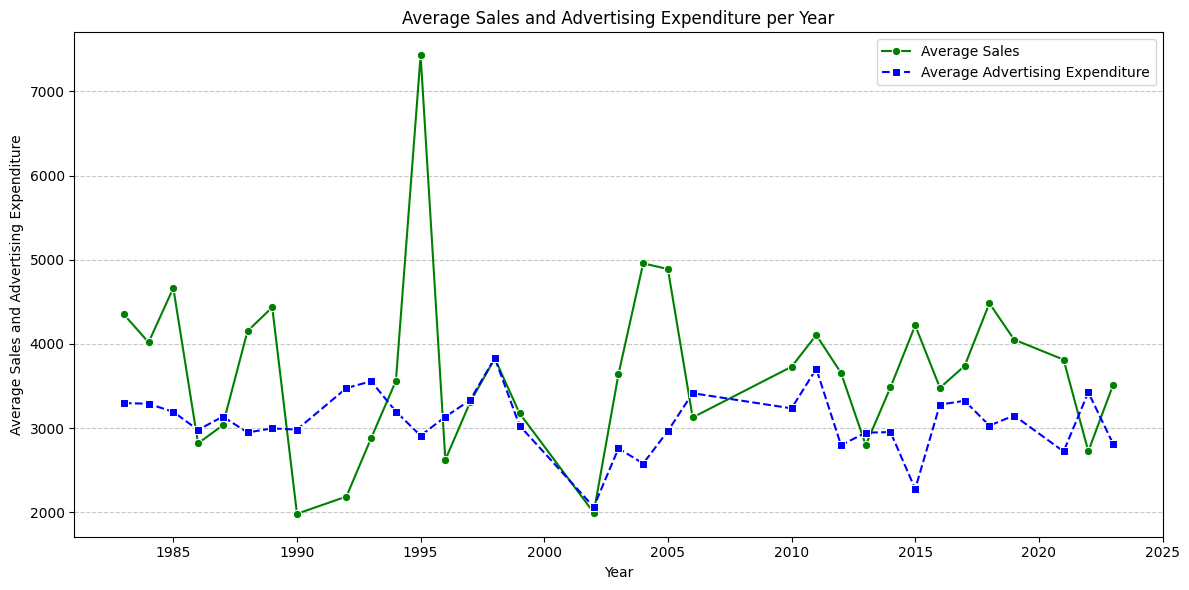

In [25]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_corr, x='Year', y='avg_sales', marker='o', linestyle='-', color='green',label = 'Average Sales')
sns.lineplot(data=df_corr, x='Year', y='avg_adv_sales', marker='s', linestyle='--', color='blue', label = 'Average Advertising Expenditure')

# Add labels, legend, title, and grid
plt.xlabel('Year')
plt.ylabel('Average Sales and Advertising Expenditure')
plt.title('Average Sales and Advertising Expenditure per Year')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

# Task 1.3

In [26]:
df_category = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()
df_category

,Recession,Automobile_Sales
0,0,3679.952998
1,1,1381.738376


([<matplotlib.axis.XTick at 0x24e8c95c150>,
 [Text(0, 0, 'Non-Recession'), Text(1, 0, 'Recession')])

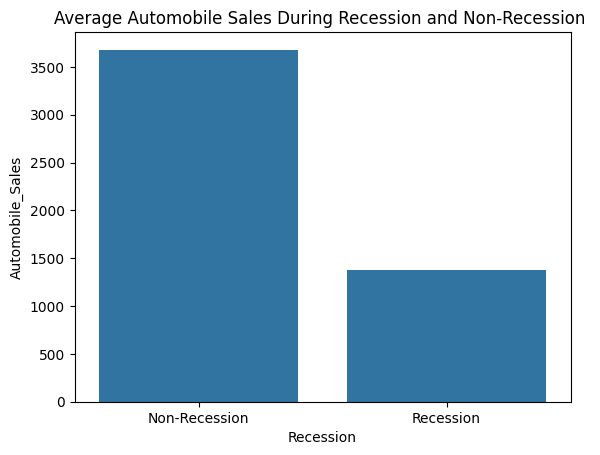

In [ ]:
sns.barplot(data=df_category,x='Recession',y='Automobile_Sales')
plt.title("Average Automobile Sales During Recession and Non-Recession ")
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])

Text(0.5, 1.0, 'Vehicle-Wise Sales during Recession and Non-Recession Period')

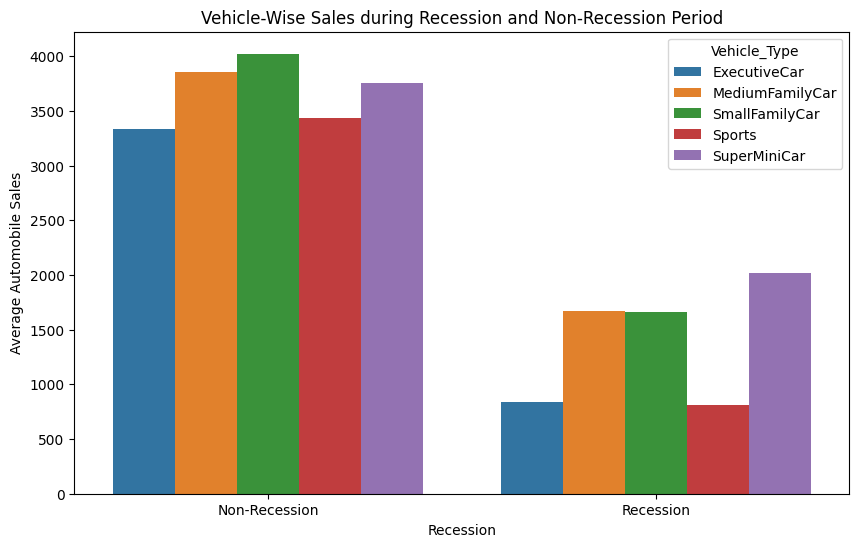

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type', data=df_rv)
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.xlabel('Recession')
plt.ylabel('Average Automobile Sales')
plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')

# Task 1.4

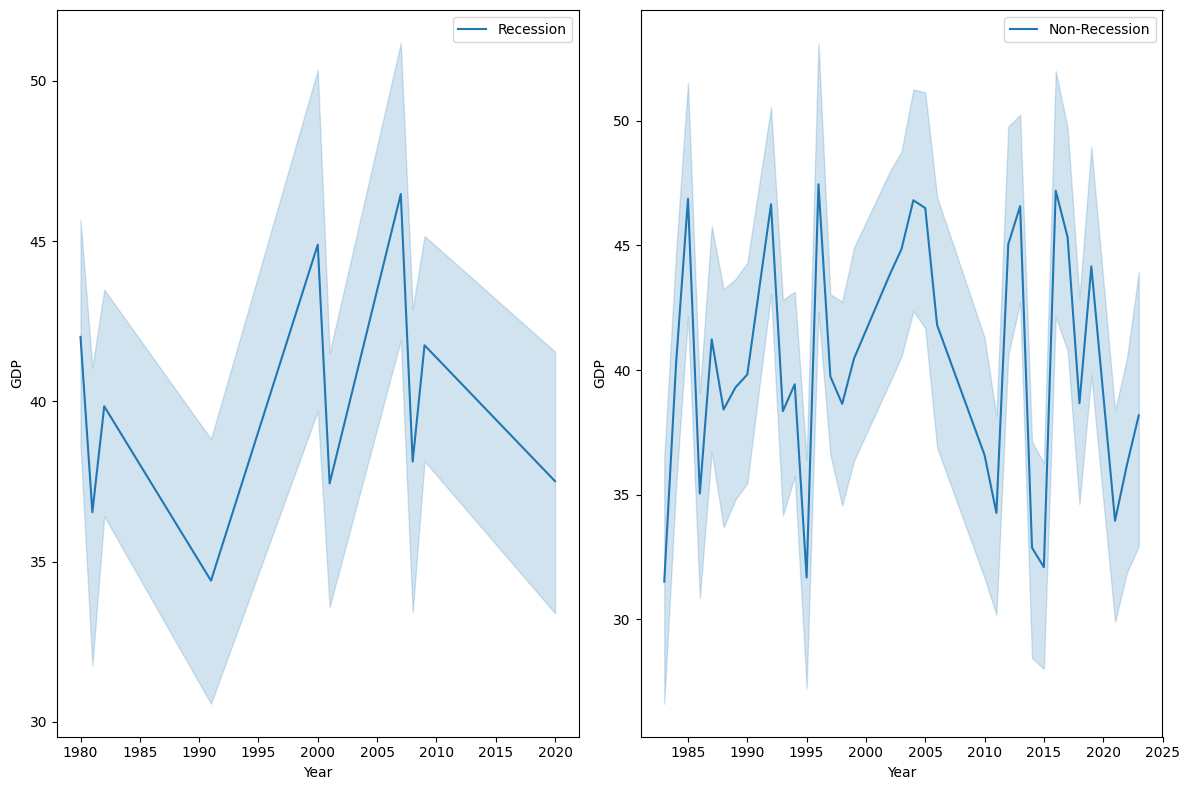

In [38]:
df_rec = df[df['Recession']==1]
df_nonrec = df[df['Recession']==0]

plt.figure(figsize=(12,8))

plt.subplot(1, 2, 1)
sns.lineplot(x='Year', y='GDP', data=df_rec, label='Recession')
plt.xlabel('Year')
plt.ylabel('GDP')
plt.legend()
#subplot 1
plt.subplot(1, 2, 2)
sns.lineplot(x='Year', y='GDP', data=df_nonrec, label='Non-Recession')
plt.xlabel('Year')
plt.ylabel('GDP')
plt.legend()
    
plt.tight_layout()
plt.show()


<Axes: xlabel='Month', ylabel='Automobile_Sales'>

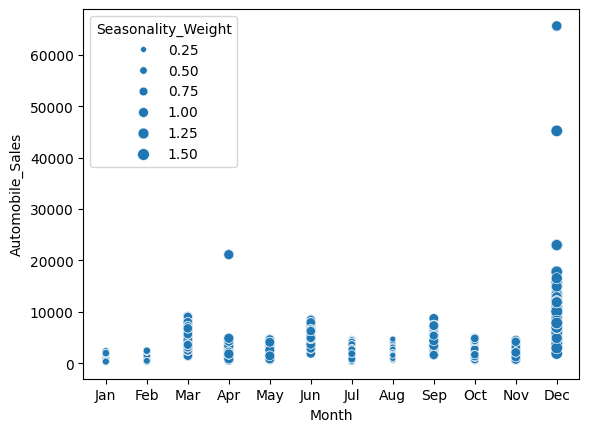

In [45]:
sns.scatterplot(data=df_nonrec,x='Month',y='Automobile_Sales',size='Seasonality_Weight')


# Task 1.6

In [51]:
df_rec.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

Text(0.5, 1.0, 'Consumer Confidence and Automobile Sales during Recessions')

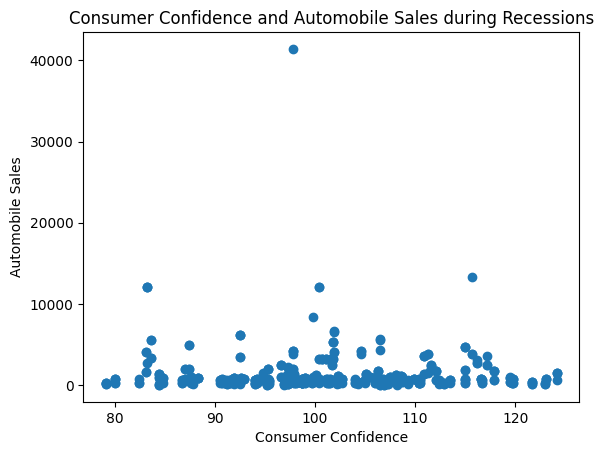

In [53]:
plt.scatter(data=df_rec,x='Consumer_Confidence',y='Automobile_Sales')
plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile Sales')
plt.title('Consumer Confidence and Automobile Sales during Recessions')

Text(0.5, 1.0, 'Relationship between Vehicle Price and Sales during Recessions')

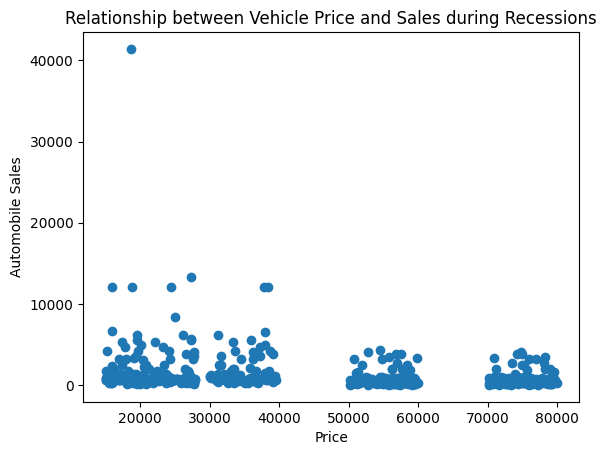

In [55]:
plt.scatter(data=df_rec,x='Price',y='Automobile_Sales')
plt.xlabel('Price')
plt.ylabel('Automobile Sales')
plt.title('Relationship between Vehicle Price and Sales during Recessions')

# Task 1.7

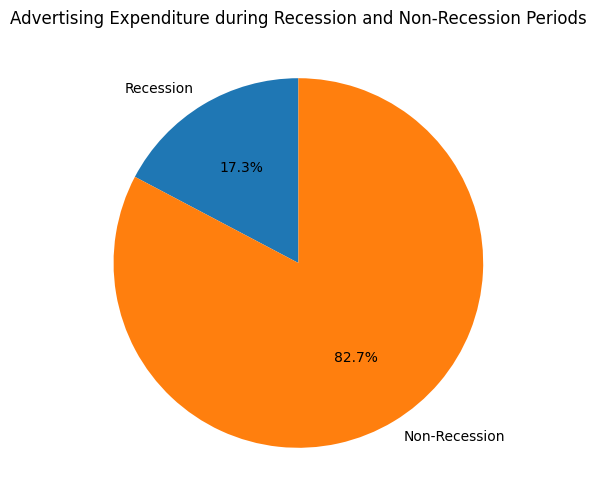

In [59]:
df_rec_sum = df_rec['Advertising_Expenditure'].sum()
df_nonrec_sum = df_nonrec['Advertising_Expenditure'].sum()
plt.figure(figsize=(8, 6))

labels = ['Recession', 'Non-Recession']
sizes = [df_rec_sum, df_nonrec_sum]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Advertising Expenditure during Recession and Non-Recession Periods')

plt.show()


# Task 1.8

In [62]:
df_vadv = df_rec.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()
df_vadv

Vehicle_Type
ExecutiveCar       152081.3
MediumFamilyCar    256663.4
SmallFamilyCar     264394.9
Sports             142555.0
SuperMiniCar       235221.0
Name: Advertising_Expenditure, dtype: float64

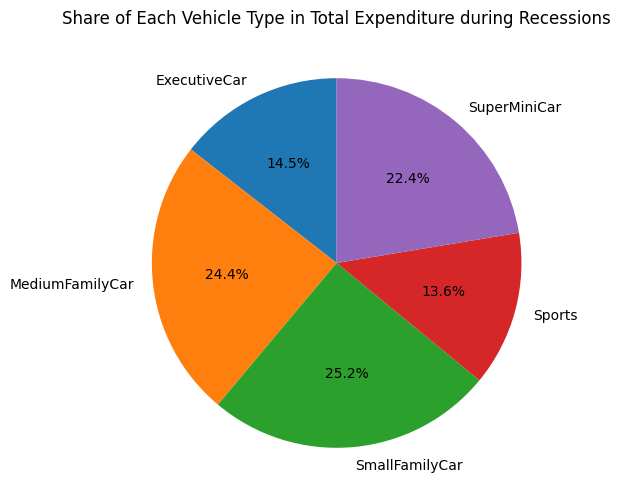

In [63]:
plt.figure(figsize=(8, 6))

labels = df_vadv.index
sizes = df_vadv.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Share of Each Vehicle Type in Total Expenditure during Recessions')

plt.show()


# Task 1.9

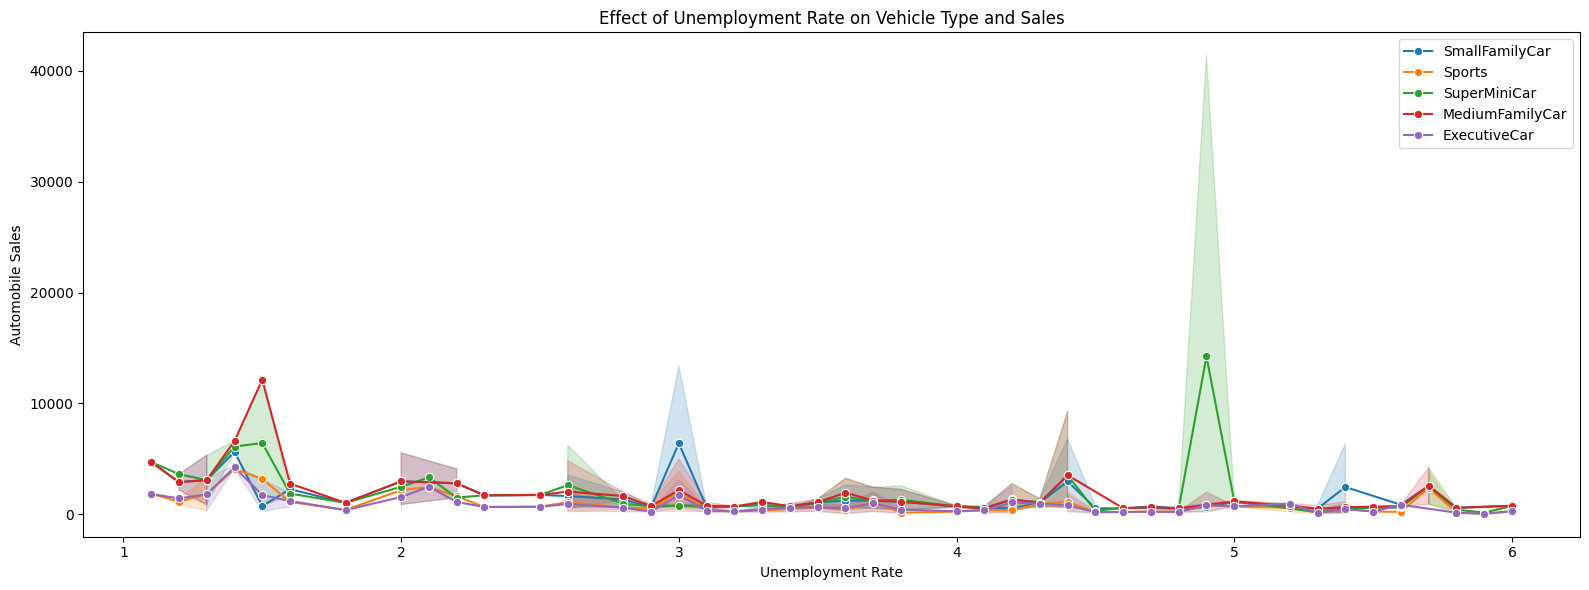

In [65]:
plt.figure(figsize=(16, 6))

# Create line plot showing effect of unemployment rate on automobile sales, by vehicle type
sns.lineplot(
    data=df_rec,
    x='unemployment_rate',               # Replace with unemployment rate column (e.g., 'unemployment_rate')
    y='Automobile_Sales',               # Replace with automobile sales column (e.g., 'Automobile_Sales')
    hue='Vehicle_Type',             # Replace with vehicle type column (e.g., 'Vehicle_Type')
    marker='o'
)

# Customize labels, legend, and title
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales')
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales')
plt.legend()

# Show plot
plt.tight_layout()
plt.show()


# Task 1.10

In [66]:
path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/us-states.json'


In [68]:
df_map = pd.read_json(path)
df_map.head()

,type,features
0,FeatureCollection,"{'type': 'Feature', 'id': 'AL', 'properties': ..."
1,FeatureCollection,"{'type': 'Feature', 'id': 'AK', 'properties': ..."
2,FeatureCollection,"{'type': 'Feature', 'id': 'AZ', 'properties': ..."
3,FeatureCollection,"{'type': 'Feature', 'id': 'AR', 'properties': ..."
4,FeatureCollection,"{'type': 'Feature', 'id': 'CA', 'properties': ..."


In [69]:
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


In [80]:
import requests

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/us-states.json'

response = requests.get(url)
with open("us-states.json", "wb") as f:
    f.write(response.content)

print("Downloaded successfully")

Downloaded successfully


In [81]:
 # Filter the data for the recession period and specific cities
recession_data = df[df['Recession'] == 1]

    # Calculate the total sales by city
sales_by_city = recession_data.groupby('City')['Automobile_Sales'].sum().reset_index()

    # Create a base map centered on the United States
map1 = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

    # Create a choropleth layer using Folium
choropleth = folium.Choropleth(
    geo_data= 'us-states.json',  # GeoJSON file with state boundaries
    data=sales_by_city,
    columns=['City', 'Automobile_Sales'],
    key_on='feature.properties.name',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Automobile Sales during Recession'
    ).add_to(map1)


    # Add tooltips to the choropleth layer
choropleth.geojson.add_child(
        folium.features.GeoJsonTooltip(['name'], labels=True)
    )

    # Display the map
map1